In [18]:
import requests
from bs4 import BeautifulSoup
import networkx as nx
import matplotlib.pyplot as plt
import time
import community as community_louvain
import networkx.algorithms.community as nx_comm
import igraph as ig
import leidenalg
from collections import defaultdict
import pandas as pd
import warnings
import os
import sys

# Configurações iniciais
warnings.filterwarnings('ignore')
plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = (14, 10)
plt.rcParams['font.size'] = 10

# Configurar backend do matplotlib para Jupyter ou script
#if 'ipykernel' in sys.modules:
#    %matplotlib inline  # Para Jupyter Notebook
#else:
#    plt.switch_backend('TkAgg')  # Para scripts Python

# Função para visualizar a rede bruta (pré-análise)
def plot_raw_network(G, pos, title, filename):
    plt.figure(figsize=(16, 12))
    
    # Calcular centralidade (tamanho dos nós)
    degrees = dict(G.degree())
    node_sizes = [v * 5 for v in degrees.values()]  # Ajuste o multiplicador conforme necessário
    
    # Plotar a rede
    nx.draw_networkx_nodes(G, pos, node_size=node_sizes, 
                          node_color='lightblue', alpha=0.7)
    nx.draw_networkx_edges(G, pos, alpha=0.1, edge_color='gray', width=0.3)
    
    # Rotular os 10 nós mais importantes
    top_nodes = sorted(degrees.items(), key=lambda x: x[1], reverse=True)[:10]
    for node, degree in top_nodes:
        label = node.split('/')[-1].replace('_', ' ').replace('%C3%', '')
        plt.text(pos[node][0], pos[node][1], label, 
                fontsize=9, ha='center', va='center',
                bbox=dict(facecolor='white', alpha=0.8, boxstyle='round,pad=0.3'))
    
    plt.title(title, fontsize=16, pad=20)
    plt.axis('off')
    
    # Adicionar estatísticas básicas
    plt.text(0.5, -0.05, 
             f"Nós: {len(G.nodes())} | Arestas: {len(G.edges())} | Densidade: {nx.density(G):.4f}",
             ha='center', va='center', transform=plt.gca().transAxes,
             bbox=dict(facecolor='white', alpha=0.5))
    
    plt.savefig(filename, dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()

# Função para plotar comunidades (pós-análise)
def plot_communities(G, pos, partition, title, filename):
    plt.figure(figsize=(16, 12))
    
    if isinstance(partition, dict):
        communities = defaultdict(set)
        for node, comm_id in partition.items():
            communities[comm_id].add(node)
        communities = list(communities.values())
    else:
        communities = partition
    
    cmap = plt.get_cmap("tab20")
    node_to_comm = {node: i for i, comm in enumerate(communities) for node in comm}
    colors = [cmap(node_to_comm[node] % 20) for node in G.nodes()]
    
    nx.draw_networkx_nodes(G, pos, node_size=80, node_color=colors, alpha=0.8)
    nx.draw_networkx_edges(G, pos, alpha=0.05, edge_color='gray', width=0.5)
    
    # Legenda de comunidades
    handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=cmap(i), markersize=12) 
               for i in range(min(20, len(communities)))]
    plt.legend(handles, [f'Comunidade {i+1}' for i in range(len(handles))], 
               loc='upper right', bbox_to_anchor=(1.15, 1))
    
    plt.title(title, fontsize=16, pad=20)
    plt.axis('off')
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()

# Função para extrair a rede via WebCrawler
def extract_network(base_url, seed_url, max_nodes=100, max_depth=2):
    G = nx.Graph()
    visited = set()
    to_visit = [(seed_url, 0)]
    
    while to_visit and len(visited) < max_nodes:
        current_url, depth = to_visit.pop(0)
        
        if current_url in visited or depth > max_depth:
            continue
            
        try:
            print(f"Processando: {current_url.split('/')[-1]}")
            resp = requests.get(current_url, timeout=10)
            soup = BeautifulSoup(resp.text, 'html.parser')
            
            title = str(soup.title.string) if soup.title else ""
            G.add_node(current_url, title=title[:100], depth=depth)
            visited.add(current_url)
            
            for link in soup.select("a[href^='/wiki/']"):
                href = link.get('href')
                if not href:
                    continue
                    
                full_url = base_url + href
                if ("Universidade" in href or "Faculdade" in href or "Instituto" in href) and ':' not in href:
                    G.add_edge(current_url, full_url)
                    if full_url not in visited and len(visited) < max_nodes:
                        to_visit.append((full_url, depth + 1))
            
            time.sleep(0.5)
            
        except Exception as e:
            print(f"Erro ao processar {current_url}: {str(e)[:100]}...")
    
    return G

# --- EXECUÇÃO PRINCIPAL ---
if __name__ == "__main__":
    # Configurações
    base_url = "https://pt.wikipedia.org"
    seed_url = base_url + "/wiki/Lista_de_universidades_do_Brasil"
    output_dir = "resultados"
    os.makedirs(output_dir, exist_ok=True)

    # 1. Extração da rede
    print("Iniciando extração da rede via WebCrawler...")
    G = extract_network(base_url, seed_url, max_nodes=100, max_depth=2)
    G.remove_nodes_from(list(nx.isolates(G)))
    print(f" Rede extraída: {len(G.nodes())} nós e {len(G.edges())} arestas")


Iniciando extração da rede via WebCrawler...
Processando: Lista_de_universidades_do_Brasil
Processando: Universidade
Processando: Instituto
Processando: Instituto_Federal_do_Acre
Processando: Universidade_Federal_do_Acre
Processando: Faculdade_Diocesana_S%C3%A3o_Jos%C3%A9
Processando: Universidade_da_Amaz%C3%B4nia
Processando: Universidade_Est%C3%A1cio_de_S%C3%A1
Processando: Universidade_Estadual_de_Alagoas
Processando: Universidade_Estadual_de_Ci%C3%AAncias_da_Sa%C3%BAde_de_Alagoas
Processando: Instituto_Federal_de_Alagoas
Processando: Universidade_Federal_de_Alagoas
Processando: Faculdade_Pit%C3%A1goras
Processando: Faculdade_Integrada_Tiradentes
Processando: Universidade_Estadual_do_Amap%C3%A1
Processando: Instituto_Federal_do_Amap%C3%A1
Processando: Universidade_Federal_do_Amap%C3%A1
Processando: Universidade_do_Estado_do_Amazonas
Processando: Instituto_Federal_do_Amazonas
Processando: Universidade_Federal_do_Amazonas
Processando: Instituto_Nacional_de_Pesquisas_da_Amaz%C3%B4nia
P


 Visualizando rede bruta...


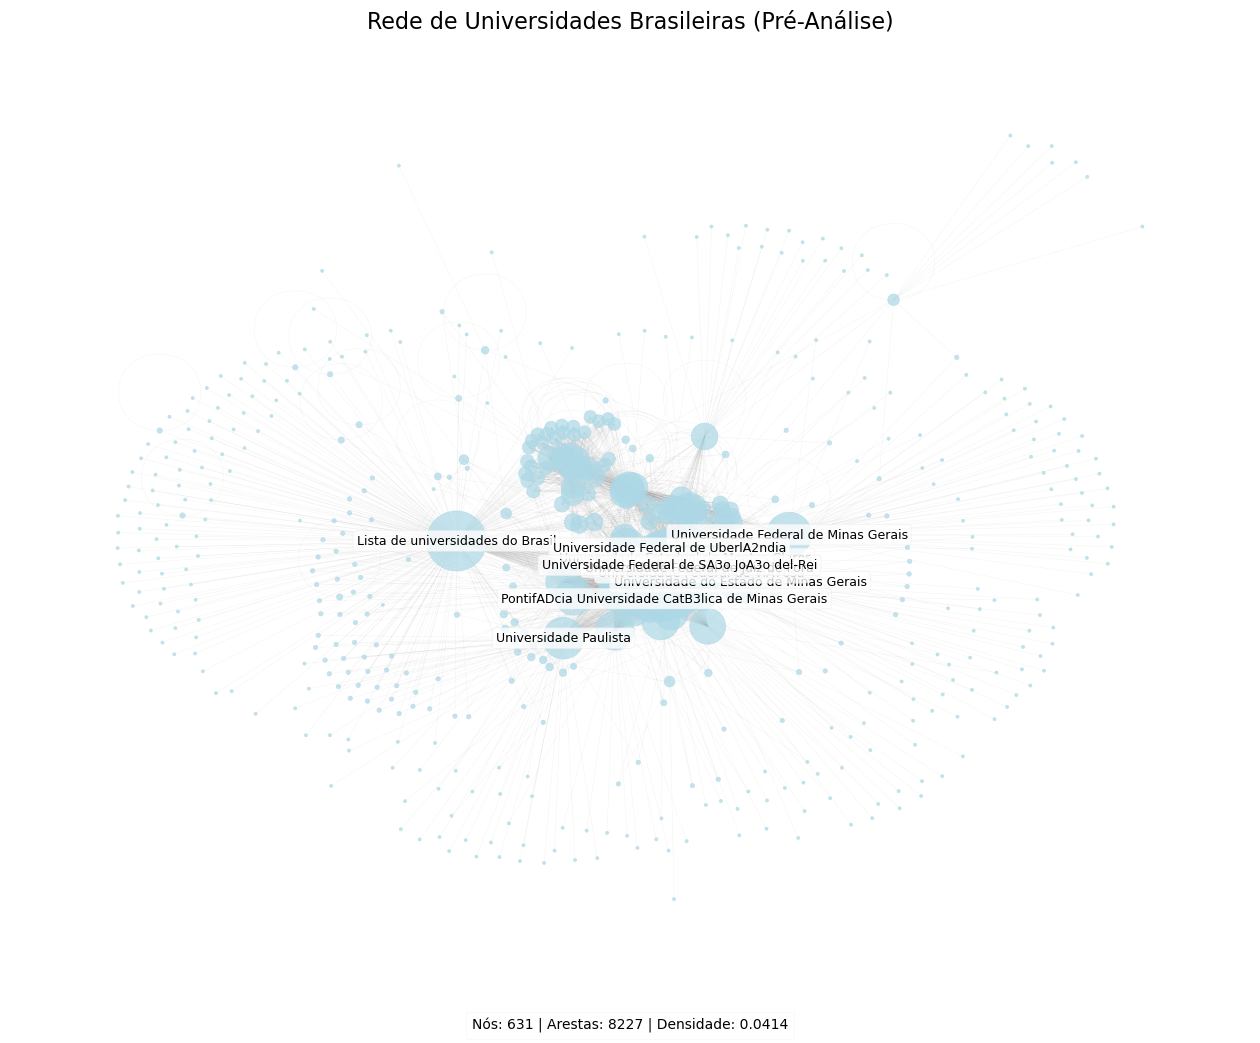


Analisando comunidades...


In [19]:
    # 2. Visualização da rede bruta
    print("\n Visualizando rede bruta...")
    pos = nx.spring_layout(G, k=0.2, iterations=100, seed=42)
    plot_raw_network(G, pos, 
                   "Rede de Universidades Brasileiras (Pré-Análise)", 
                   f"{output_dir}/rede_bruta.png")

    # 3. Análise de comunidades
    print("\nAnalisando comunidades...")
    results = []

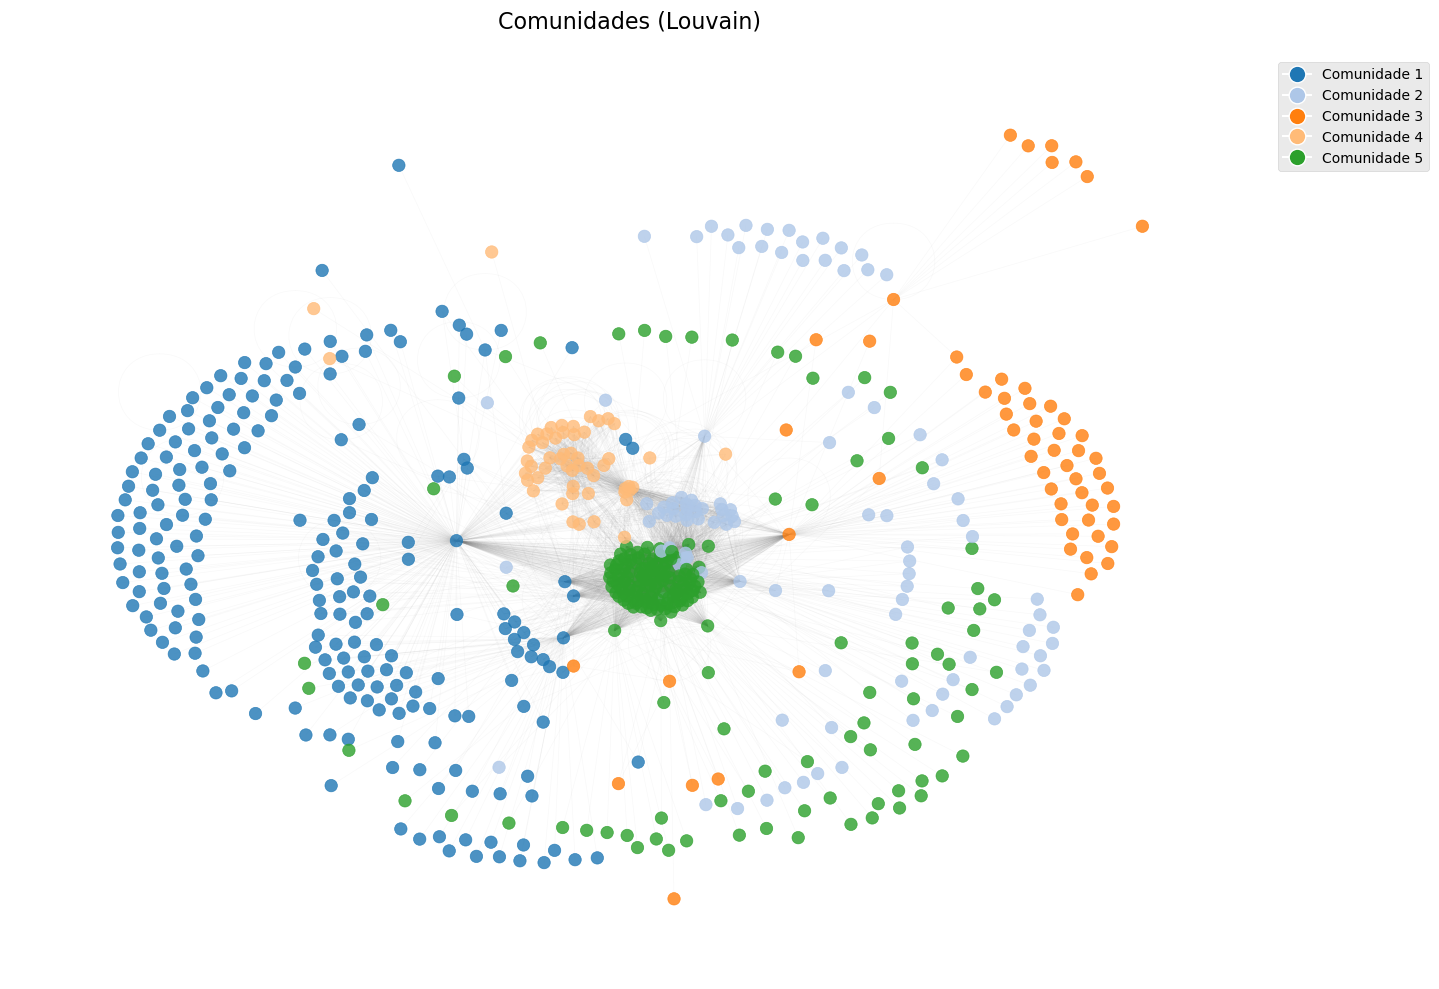

In [20]:
    # Louvain
    start = time.time()
    partition_louvain = community_louvain.best_partition(G)
    metrics_louvain = calculate_metrics(G, partition_louvain, "Louvain", time.time() - start)
    results.append(metrics_louvain)
    plot_communities(G, pos, partition_louvain, 
                    "Comunidades (Louvain)", 
                    f"{output_dir}/comunidades_louvain.png")

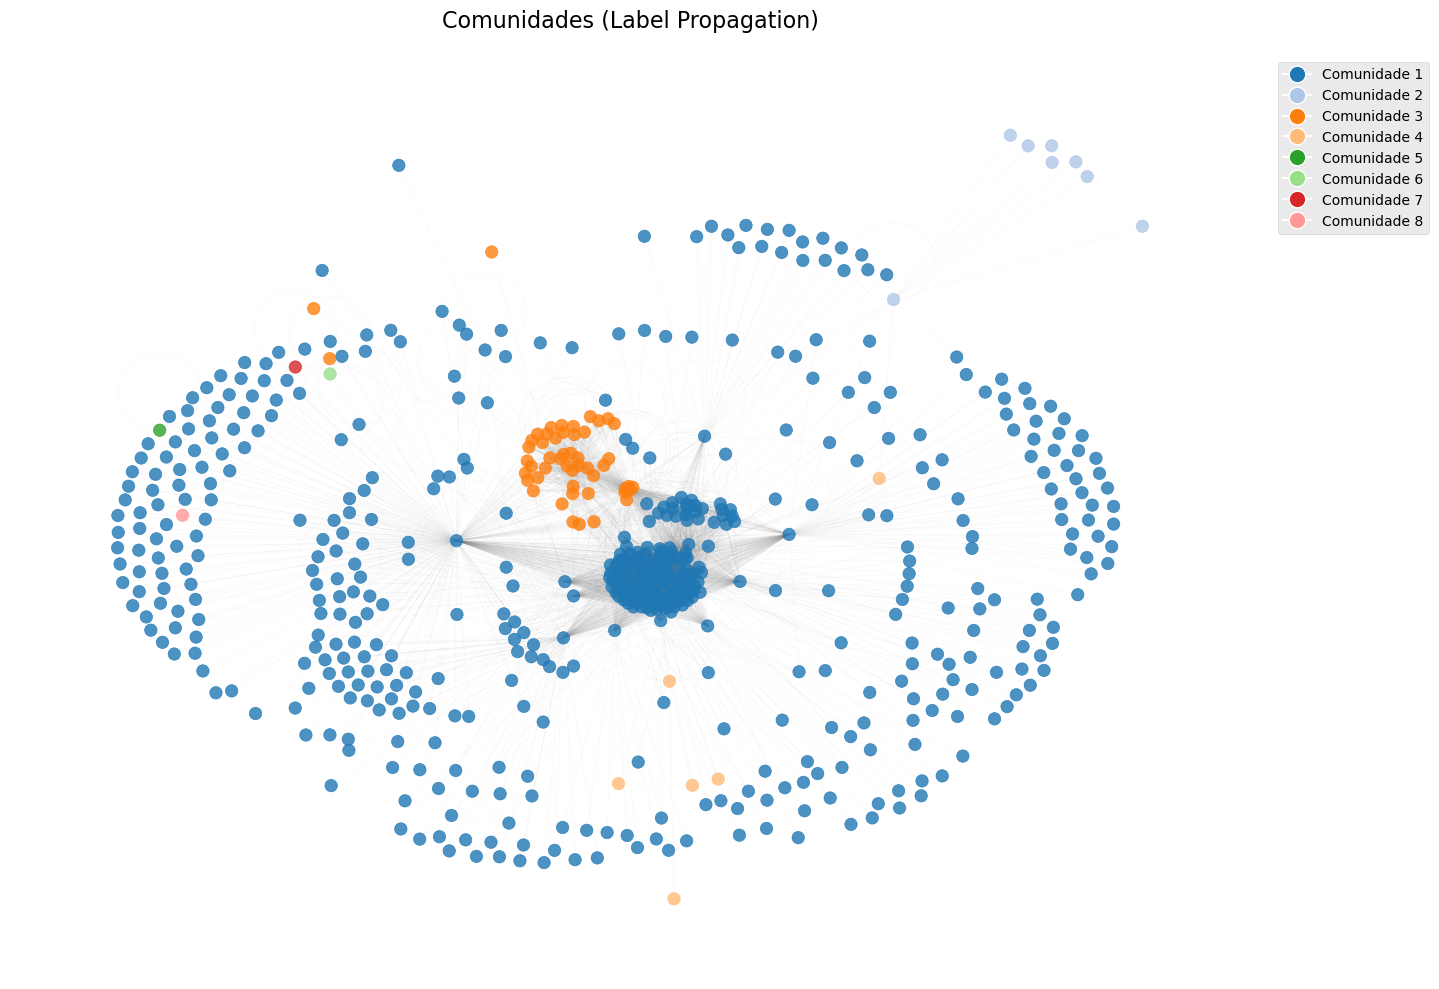

In [21]:
    # Label Propagation
    start = time.time()
    communities_lpa = list(nx_comm.label_propagation_communities(G))
    metrics_lpa = calculate_metrics(G, communities_lpa, "Label Propagation", time.time() - start)
    results.append(metrics_lpa)
    plot_communities(G, pos, communities_lpa, 
                    "Comunidades (Label Propagation)", 
                    f"{output_dir}/comunidades_lpa.png")

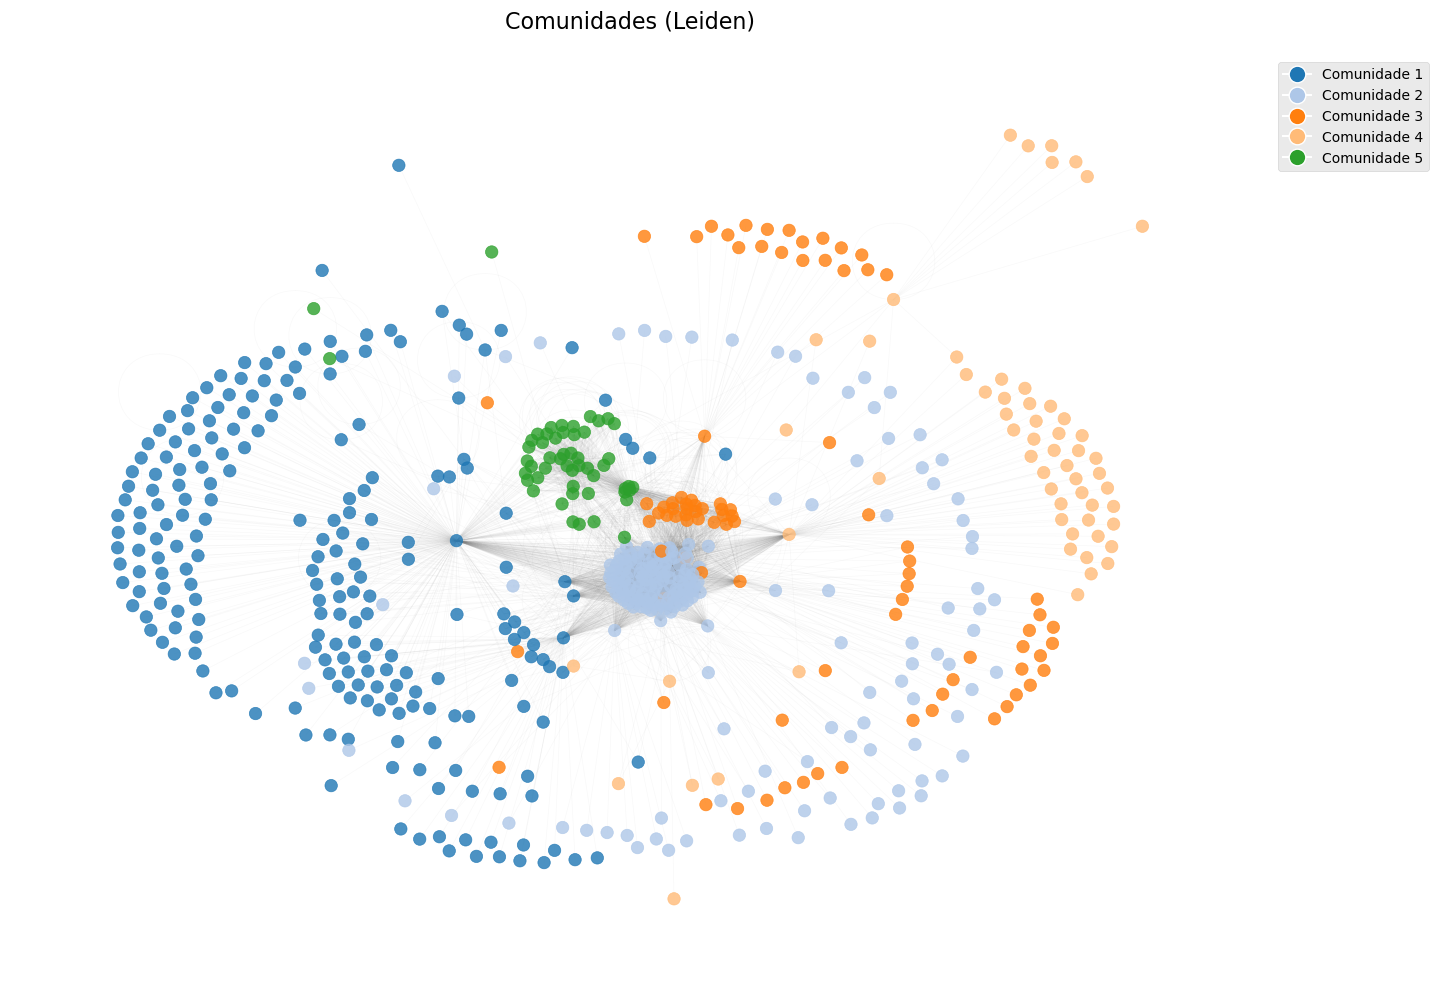

In [23]:
# Leiden
start = time.time()
G_ig = ig.Graph.TupleList(G.edges(), directed=False)

# Obter a partição
partition_leiden = leidenalg.find_partition(G_ig, leidenalg.ModularityVertexPartition)

# Converter para lista de conjuntos (formato que o NetworkX espera)
communities_leiden = [set(G_ig.vs[node]['name'] for node in comm) for comm in partition_leiden]

# Converter para dicionário (para visualização)
partition_leiden_nx = {G_ig.vs[node]['name']: i for i, comm in enumerate(partition_leiden) for node in comm}

metrics_leiden = calculate_metrics(G, communities_leiden, "Leiden", time.time() - start)
results.append(metrics_leiden)
plot_communities(G, pos, partition_leiden_nx, 
                "Comunidades (Leiden)", 
                f"{output_dir}/comunidades_leiden.png")


=== Resultados Comparativos ===
              Método  Modularidade  Comunidades  Maior comunidade  \
0            Louvain      0.261958            5               214   
1  Label Propagation      0.146845            8               562   
2             Leiden      0.259866            5               217   

   Menor comunidade  Tamanho médio  Tempo (s)  
0                54         126.20       0.08  
1                 1          78.88       0.03  
2                52         126.20       0.01  


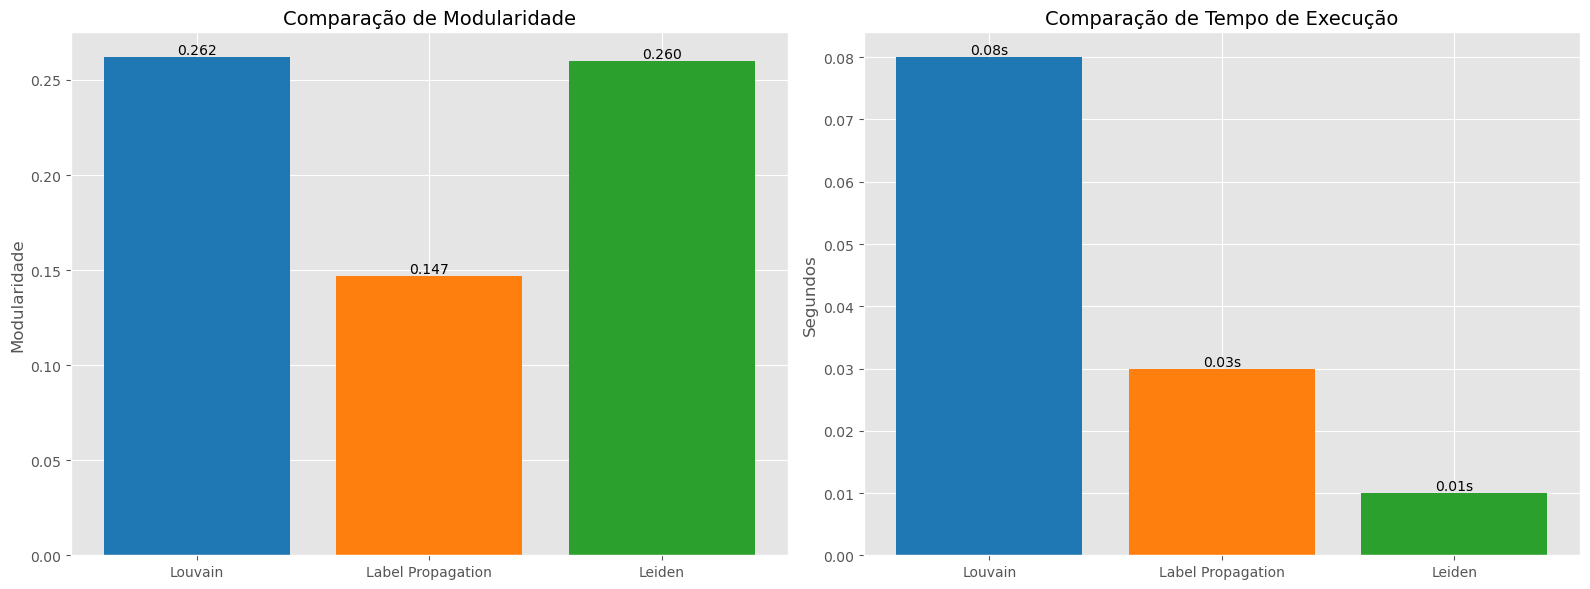


Preparando para salvar a rede...
Rede salva como 'resultados/rede_universidades.gexf'
Métricas salvas em 'resultados/metricas_comunidades.csv'

Processo concluído com sucesso! Verifique a pasta 'resultados' para os arquivos gerados.


In [24]:
# Resultados comparativos
print("\n=== Resultados Comparativos ===")
results_df = pd.DataFrame(results)
print(results_df)

# Plot comparativo
plt.figure(figsize=(16, 6))
plt.subplot(121)
bars = plt.bar(results_df['Método'], results_df['Modularidade'], 
               color=['#1f77b4', '#ff7f0e', '#2ca02c'])
plt.title('Comparação de Modularidade', fontsize=14)
plt.ylabel('Modularidade', fontsize=12)
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.3f}',
             ha='center', va='bottom')

plt.subplot(122)
bars = plt.bar(results_df['Método'], results_df['Tempo (s)'], 
               color=['#1f77b4', '#ff7f0e', '#2ca02c'])
plt.title('Comparação de Tempo de Execução', fontsize=14)
plt.ylabel('Segundos', fontsize=12)
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.2f}s',
             ha='center', va='bottom')

plt.tight_layout()
plt.savefig('comparacao_metodos.png', dpi=300, bbox_inches='tight')
plt.show()

# Preparar para salvar a rede
print("\nPreparando para salvar a rede...")

# Limpar atributos para serialização
for node in G.nodes():
    node_data = G.nodes[node]
    for key, value in list(node_data.items()):
        node_data[key] = str(value)[:200]  # Limita a 200 caracteres

# Criar diretório para resultados
os.makedirs('resultados', exist_ok=True)

# Salvar a rede em formato GEXF
try:
    nx.write_gexf(G, "resultados/rede_universidades.gexf")
    print("Rede salva como 'resultados/rede_universidades.gexf'")
except Exception as e:
    print(f"Erro ao salvar como GEXF: {str(e)[:100]}...")

# Salvar resultados em CSV
results_df.to_csv('resultados/metricas_comunidades.csv', index=False)
print("Métricas salvas em 'resultados/metricas_comunidades.csv'")

print("\nProcesso concluído com sucesso! Verifique a pasta 'resultados' para os arquivos gerados.")

1. Objetivo do Projeto
O projeto visa extrair e analisar uma rede de universidades brasileiras a partir da Wikipedia, utilizando técnicas de Web Crawling e Análise de Redes Complexas. O foco é identificar comunidades (grupos fortemente conectados) dentro dessa rede, aplicando três algoritmos diferentes: Louvain, Label Propagation e Leiden

O Web Crawler desenvolvido no código tem a função de extrair automaticamente informações sobre universidades brasileiras da Wikipedia, construindo uma rede de relacionamentos entre elas.

O que é Coletado?
Nós (Vértices): Cada universidade, faculdade ou instituto listado na Wikipedia.

Exemplo: Universidade_Federal_do_Rio_de_Janeiro, Instituto_Federal_do_Ceará.

Arestas (Links): Conexões entre páginas de universidades, indicando relacionamentos.

Exemplo: Se a página da UFMG tem um link para a UFBA, isso gera uma aresta UFMG → UFBA.

Como a Coleta é Feita?
Página Inicial (Seed URL):

Começa pela página "Lista de Universidades do Brasil".

Busca em Profundidade Limitada:

O crawler segue links apenas de páginas relacionadas a:

Universidade, Faculdade, Instituto.

Limite de 2 níveis de profundidade (para evitar extração excessiva).

Filtros:

Ignora páginas com : (categorias, discussões, etc.).

Armazena apenas URLs válidas dentro do domínio da Wikipedia.

Estrutura de Dados:

A rede é armazenada em um grafo (NetworkX), onde:

Vértice (Nó): Nome da universidade (URL formatada).

Aresta: Link entre duas universidades.

Resultado da Coleta
Grafo com 631 nós e 8.227 arestas (conexões).

O que os Nós e Arestas Representam?

Nó (Vértice): Uma instituição de ensino.

Aresta: Indica que há um link entre duas universidades na Wikipedia (pode sugerir relações como parceri

a2. Detecção de Comunidades
Após a coleta, três algoritmos são usados para identificar grupos (comunidades) de universidades fortemente conectadas:

Algoritmos Utilizados
Algoritmo	Descrição	Resultados no Projeto
Louvain	Otimiza a modularidade (agrupa nós para maximizar conexões internas).	5 comunidades
Label Propagation	Propaga "rótulos" entre nós vizinhos (rápido, mas menos preciso).	8 comunidades
Leiden	Similar ao Louvain, mas garante comunidades mais conectadas.	5 comun
O que os Resultados Significam?
Modularidade (0 a 1):

Mede quão bem separadas estão as comunidades.

Quanto mais próximo de 1, melhor a divisão.

Louvain (0.262) e Leiden (0.260) tiveram os melhores resultados.

Número de Comunidades:

Louvain/Leiden: 5 grupos.

Label Propagation: 8 grupos (mas com uma comunidade gigante de 562 nós, o que indica desbalanceamento).

Tamanho das Comunidades:

Maior comunidade: ~214-217 nós (Louvain/Leiden).

Menor comunidade: ~52-54 nós.

Interpretação das Comunidades
Comunidades Grandes (200+ nós):

Provavelmente incluem universidades federais e estaduais (ex.: UFMG, UFRJ, USP), que têm mais links na Wikipedia.

Comunidades Pequenas (50-100 nós):

Podem representar institutos federais ou faculdades privadas com menos conexões.

Label Propagation Desbalanceado:

Criou uma "super comunidade" com 562 nós, o que sugere que o algoritmo não

Resumo Final
Web Crawler coleta universidades e seus links na Wikipedia, formando um grafo.

Nós = Universidades, Arestas = Links entre elas.

Comunidades identificam grupos com conexões fortes (ex.: federais x privadas).

Louvain/Leiden são melhores que Label Propagation para essa análise. é ideal para redes acadêmicas.
idades
s, comparações ou referências acadêmicas).

.